### Cnn layers

In [5]:

def conv2d(img_array, _filter, padding, stride):

    img_row_len, img_col_len = img_array.shape
    fltr_len = _filter.shape[0] # filter is a square matrix as row len == col len
    
    output_row_size = ((img_row_len - fltr_len + 2*padding)/stride) + 1  # if decimal then invalid padding / filter / stride
    output_col_size = ((img_col_len - fltr_len + 2*padding)/stride) + 1
    
    if (output_row_size != int(output_row_size)) or (output_col_size != int(output_col_size)):
        raise Exception("row and col size should be an integers not float")
        
    output_row_size = int(output_row_size)
    output_col_size = int(output_col_size)

    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(img_row_len - fltr_len + 1)):
        for j in range(img_col_len - fltr_len + 1):
            result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
    return result

def calculate_output_size_after_pooling(input_size, pool_size):
    remainder, quotient = input_size % pool_size[0], input_size // pool_size[0]
    if quotient >= 1:
        if remainder > 0:
            output_size = quotient + 1
        else:
            output_size = quotient
    else:
        output_size = 1
    return output_size

def pooling(img_array, pool_size, mode="max"):
    row, col = img_array.shape
    output_row_size = calculate_output_size_after_pooling(row, pool_size)
    output_col_size = calculate_output_size_after_pooling(col, pool_size)
    print(output_row_size, output_col_size)
    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(output_row_size)):
        for j in range(output_col_size):
            start_row = pool_size[0]*i
            end_row = pool_size[0]*i+pool_size[0]
            start_col = pool_size[1]*j
            end_col = pool_size[1]*j+pool_size[1]
            # print(img_array[start_row:end_row, start_col:end_col])
            # print("-------", start_row, end_row, start_col, end_col)
            if mode == "max":
                result[i, j] = np.max(img_array[start_row:end_row, start_col:end_col])
            elif mode == "average":
                result[i, j] = np.mean(img_array[start_row:end_row, start_col:end_col])
        # print("+++++++++")

            # print(np.max(img_array[i:i+2, j:j+2]))
            
    return result

In [14]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math
from PIL import Image


def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('cat.jpg')
img = rgb2gray(img)
im = Image.fromarray(img)
im.save(f"exps/cat_gray.tif")

filters = np.array([[[-1, 1, 0],[-1, 1, 0],[-1, 1, 0]],[[0, 1, -1],[0, 1, -1],[0, 1, -1]], [[-1, -1, -1],[1, 1, 1],[0, 0, 0]], [[0, 0, 0],[1, 1, 1],[-1, -1, -1]]])
# print(filter_sharpen)

padding = 1

stride = 1
pool_size = (2,2)

for i in range(4):
    print(filters[i])
    img_array = conv2d(img, filters[i], padding, stride)
    print(img_array.shape)
    im = Image.fromarray(img_array)
    im.save(f"exps3/cat_filtered_{i}.tif")
    pooled_array = pooling(img_array, pool_size, mode="average")
    print(pooled_array.shape)
    im = Image.fromarray(pooled_array)
    im.save(f"exps3/cat_pooled_{i}.tif")
    
    # plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)

[[-1  1  0]
 [-1  1  0]
 [-1  1  0]]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1498/1498 [00:10<00:00, 147.87it/s]


(1500, 1000)
750 500


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 750/750 [00:03<00:00, 236.85it/s]


(750, 500)
[[ 0  1 -1]
 [ 0  1 -1]
 [ 0  1 -1]]


...

(750, 500)
[[ 0  0  0]
 [ 1  1  1]
 [-1 -1 -1]]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1498/1498 [00:10<00:00, 147.14it/s]


(1500, 1000)
750 500


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 750/750 [00:03<00:00, 223.52it/s]

(750, 500)


In [16]:
img = mpimg.imread('cat.jpg')
img = rgb2gray(img)
im = Image.fromarray(img)
im.save(f"exps3/cat_gray.tif")

In [17]:
from PIL import Image
img = Image.open('cat.jpg').convert('L')
img.save('exps3/cat_gray.tif')

In [20]:
# visualize feature maps output from each block in the vgg model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import load_img
from keras.preprocessing.image import img_to_array
from keras.models import Model
from matplotlib import pyplot
from numpy import expand_dims
# load the model
model = VGG16()
# redefine model to output right after the first hidden layer
ixs = [2, 5, 9, 13, 17]
outputs = [model.layers[i].output for i in ixs]
model = Model(inputs=model.inputs, outputs=outputs)
# load the image with the required shape
img = load_img('bird.jpg', target_size=(224, 224))
# convert the image to an array
img = img_to_array(img)
# expand dimensions so that it represents a single 'sample'
img = expand_dims(img, axis=0)
# prepare the image (e.g. scale pixel values for the vgg)
img = preprocess_input(img)
# get feature map for first hidden layer
feature_maps = model.predict(img)
# plot the output from each block
square = 8
for fmap in feature_maps:
	# plot all 64 maps in an 8x8 squares
	ix = 1
	for _ in range(square):
		for _ in range(square):
			# specify subplot and turn of axis
			ax = pyplot.subplot(square, square, ix)
			ax.set_xticks([])
			ax.set_yticks([])
			# plot filter channel in grayscale
			pyplot.imshow(fmap[0, :, :, ix-1], cmap='gray')
			ix += 1
	# show the figure
	pyplot.show()

ImportError: cannot import name 'img_to_array' from 'keras.preprocessing.image' (/opt/anaconda3/lib/python3.9/site-packages/keras/preprocessing/image.py)

In [1]:
import tensorflow as tf

model=tf.keras.models.Sequential([
    
    tf.keras.layers.Conv2D(8,(3,3),activation ='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(16,(3,3),activation ='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32,(3,3),activation ='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(1024,activation='relu'),
    tf.keras.layers.Dense(512,activation='relu'),
    
    tf.keras.layers.Dense(3,activation='softmax')    
 ])

2023-01-08 19:24:20.208401: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 8)       224       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 8)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 16)        1168      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 16)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 32)        4640      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 32)       0

In [3]:
layer_names = [layer.name for layer in model.layers]
layer_names

['conv2d',
 'max_pooling2d',
 'conv2d_1',
 'max_pooling2d_1',
 'conv2d_2',
 'max_pooling2d_2',
 'flatten',
 'dense',
 'dense_1',
 'dense_2']

In [4]:
model.layers

In [5]:
layer_outputs = [layer.output for layer in model.layers]

In [6]:
layer_outputs

[<KerasTensor: shape=(None, 148, 148, 8) dtype=float32 (created by layer 'conv2d')>,
 <KerasTensor: shape=(None, 74, 74, 8) dtype=float32 (created by layer 'max_pooling2d')>,
 <KerasTensor: shape=(None, 72, 72, 16) dtype=float32 (created by layer 'conv2d_1')>,
 <KerasTensor: shape=(None, 36, 36, 16) dtype=float32 (created by layer 'max_pooling2d_1')>,
 <KerasTensor: shape=(None, 34, 34, 32) dtype=float32 (created by layer 'conv2d_2')>,
 <KerasTensor: shape=(None, 17, 17, 32) dtype=float32 (created by layer 'max_pooling2d_2')>,
 <KerasTensor: shape=(None, 9248) dtype=float32 (created by layer 'flatten')>,
 <KerasTensor: shape=(None, 1024) dtype=float32 (created by layer 'dense')>,
 <KerasTensor: shape=(None, 512) dtype=float32 (created by layer 'dense_1')>,
 <KerasTensor: shape=(None, 3) dtype=float32 (created by layer 'dense_2')>]

In [9]:
feature_map_model = tf.keras.models.Model(model.input, layer_outputs)

In [13]:
from tensorflow.keras.utils import load_img, img_to_array

image_path= r"cat.jpg"
img = load_img(image_path, target_size=(150, 150))  
input = img_to_array(img)                           
input = input.reshape((1,) + input.shape)                   
input /= 255.0

In [14]:
feature_maps = feature_map_model.predict(input)

1/1 [==============================] - 0s 323ms/step


In [15]:
for layer_name, feature_map in zip(layer_names, feature_maps):
    print(f"The shape of the {layer_name} is =======>> {feature_map.shape}")

The shape of the conv2d is =======>> (1, 148, 148, 8)
The shape of the max_pooling2d is =======>> (1, 74, 74, 8)
The shape of the conv2d_1 is =======>> (1, 72, 72, 16)
The shape of the max_pooling2d_1 is =======>> (1, 36, 36, 16)
The shape of the conv2d_2 is =======>> (1, 34, 34, 32)
The shape of the max_pooling2d_2 is =======>> (1, 17, 17, 32)
The shape of the flatten is =======>> (1, 9248)
The shape of the dense is =======>> (1, 1024)
The shape of the dense_1 is =======>> (1, 512)
The shape of the dense_2 is =======>> (1, 3)


In [20]:
import numpy as np

for layer_name, feature_map in zip(layer_names, feature_maps):  
    if len(feature_map.shape) == 4:
        k = feature_map.shape[-1]  
        size=feature_map.shape[1]
        for i in range(k):
            feature_image = feature_map[0, :, :, i]
            feature_image-= feature_image.mean()
            feature_image/= feature_image.std ()
            feature_image*=  64
            feature_image+= 128
            feature_image= np.clip(input, 0, 255).astype('uint8')
            image_belt[:, i * size : (i + 1) * size] = feature_image
        
scale = 20. / k
plt.figure( figsize=(scale * k, scale) )
plt.title ( layer_name )
plt.grid  ( False )
plt.imshow( image_belt, aspect='auto')

NameError: name 'image_belt' is not defined

In [21]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
from matplotlib import pyplot
from numpy import expand_dims
from matplotlib import pyplot

import warnings
warnings.filterwarnings('ignore')

In [22]:
model = VGG16()

In [23]:
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [24]:
for layer in model.layers:
    
    if 'conv' not in layer.name:
        continue    
    filters , bias = layer.get_weights()
    print(layer.name , filters.shape)

block1_conv1 (3, 3, 3, 64)
block1_conv2 (3, 3, 64, 64)
block2_conv1 (3, 3, 64, 128)
block2_conv2 (3, 3, 128, 128)
block3_conv1 (3, 3, 128, 256)
block3_conv2 (3, 3, 256, 256)
block3_conv3 (3, 3, 256, 256)
block4_conv1 (3, 3, 256, 512)
block4_conv2 (3, 3, 512, 512)
block4_conv3 (3, 3, 512, 512)
block5_conv1 (3, 3, 512, 512)
block5_conv2 (3, 3, 512, 512)
block5_conv3 (3, 3, 512, 512)


In [25]:
# retrieve weights from the second hidden layer
filters , bias = model.layers[1].get_weights()

In [26]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

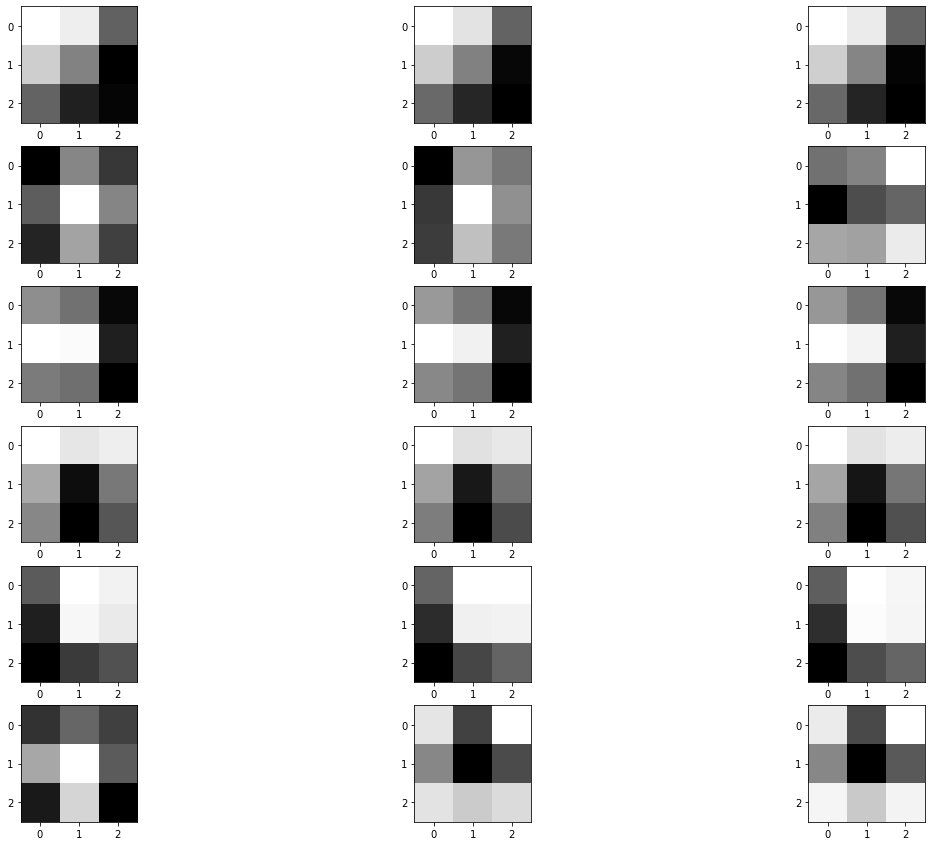

In [27]:
n_filters =6
ix=1
fig = pyplot.figure(figsize=(20,15))
for i in range(n_filters):
    # get the filters
    f = filters[:,:,:,i]
    for j in range(3):
        # subplot for 6 filters and 3 channels
        pyplot.subplot(n_filters,3,ix)
        pyplot.imshow(f[:,:,j] ,cmap='gray')
        ix+=1
#plot the filters 
pyplot.show()

In [29]:
for i in range(len(model.layers)):
    layer = model.layers[i]
    # if 'conv' not in layer.name:
     #   continue    
    print(i , layer.name , layer.output.shape)

0 input_1 (None, 224, 224, 3)
1 block1_conv1 (None, 224, 224, 64)
2 block1_conv2 (None, 224, 224, 64)
3 block1_pool (None, 112, 112, 64)
4 block2_conv1 (None, 112, 112, 128)
5 block2_conv2 (None, 112, 112, 128)
6 block2_pool (None, 56, 56, 128)
7 block3_conv1 (None, 56, 56, 256)
8 block3_conv2 (None, 56, 56, 256)
9 block3_conv3 (None, 56, 56, 256)
10 block3_pool (None, 28, 28, 256)
11 block4_conv1 (None, 28, 28, 512)
12 block4_conv2 (None, 28, 28, 512)
13 block4_conv3 (None, 28, 28, 512)
14 block4_pool (None, 14, 14, 512)
15 block5_conv1 (None, 14, 14, 512)
16 block5_conv2 (None, 14, 14, 512)
17 block5_conv3 (None, 14, 14, 512)
18 block5_pool (None, 7, 7, 512)
19 flatten (None, 25088)
20 fc1 (None, 4096)
21 fc2 (None, 4096)
22 predictions (None, 1000)


In [30]:
model = Model(inputs=model.inputs , outputs=model.layers[1].output)

In [32]:
image = load_img("cat.jpg" , target_size=(224,224))
# convert the image to an array
image = img_to_array(image)
# expand dimensions so that it represents a single 'sample'
image = expand_dims(image, axis=0)

In [33]:

image = preprocess_input(image)

1/1 [==============================] - 0s 44ms/step


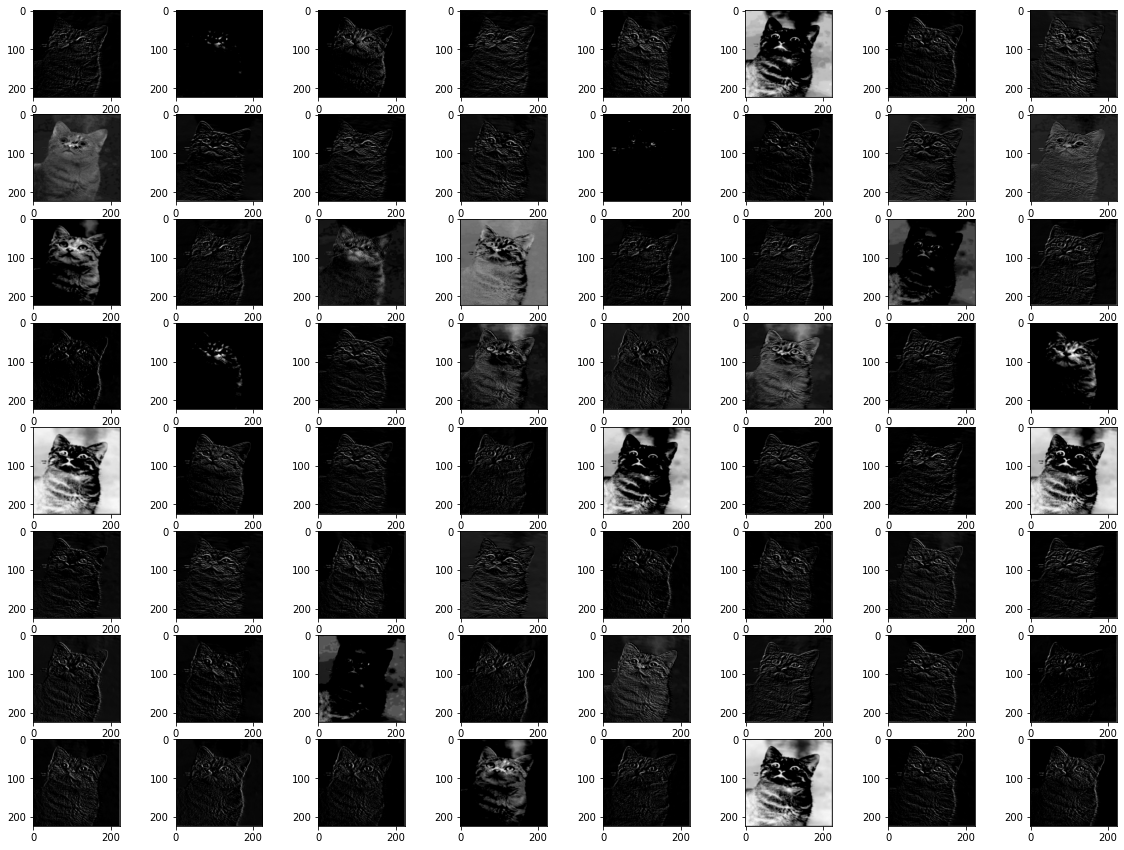

In [34]:
#calculating features_map
features = model.predict(image)

fig = pyplot.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):

    pyplot.subplot(8,8,i)
    pyplot.imshow(features[0,:,:,i-1] , cmap='gray')
    
pyplot.show()

In [35]:
model2 = VGG16()

In [36]:
blocks = [ 2, 5 , 9 , 13 , 17]
outputs = [model2.layers[i].output for i in blocks]

model2 = Model( inputs= model2.inputs, outputs = outputs)

1/1 [==============================] - 0s 260ms/step


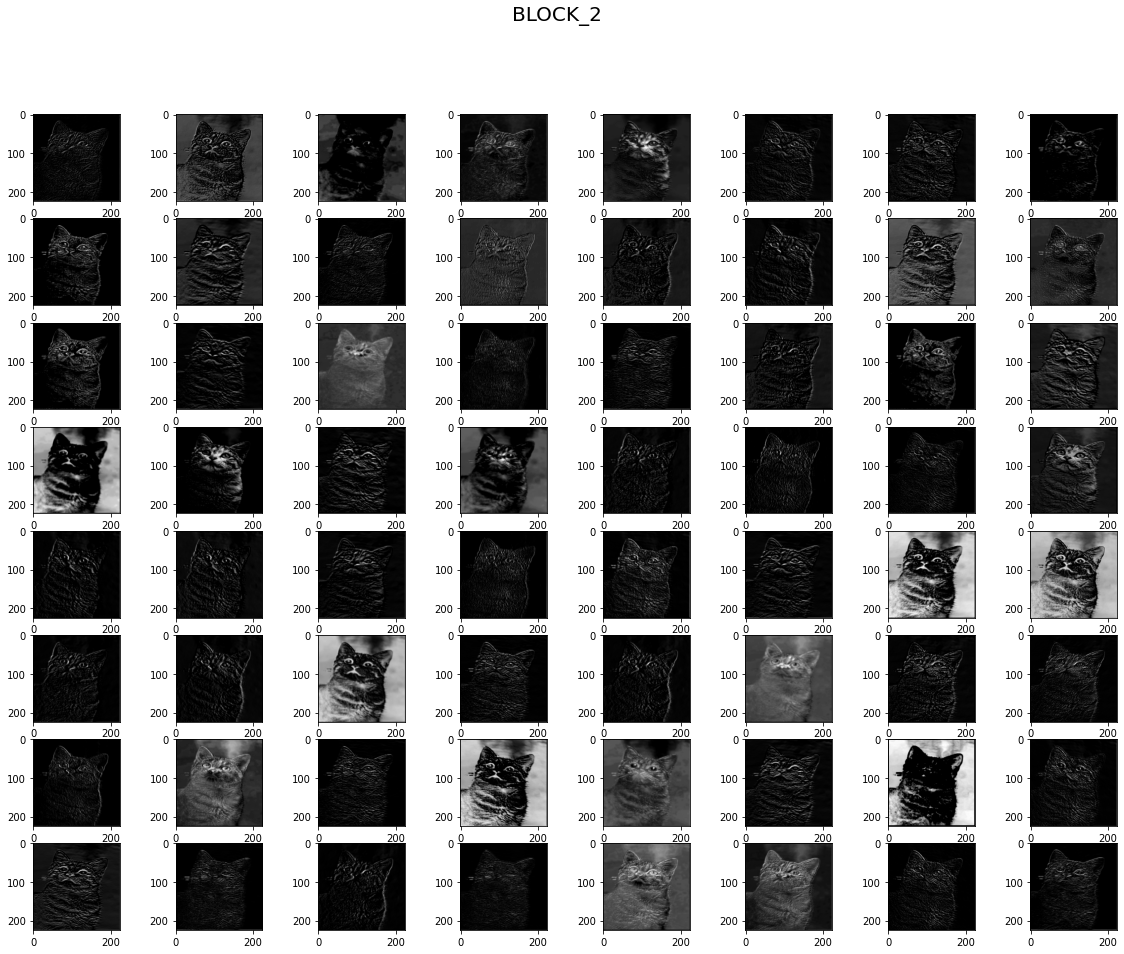

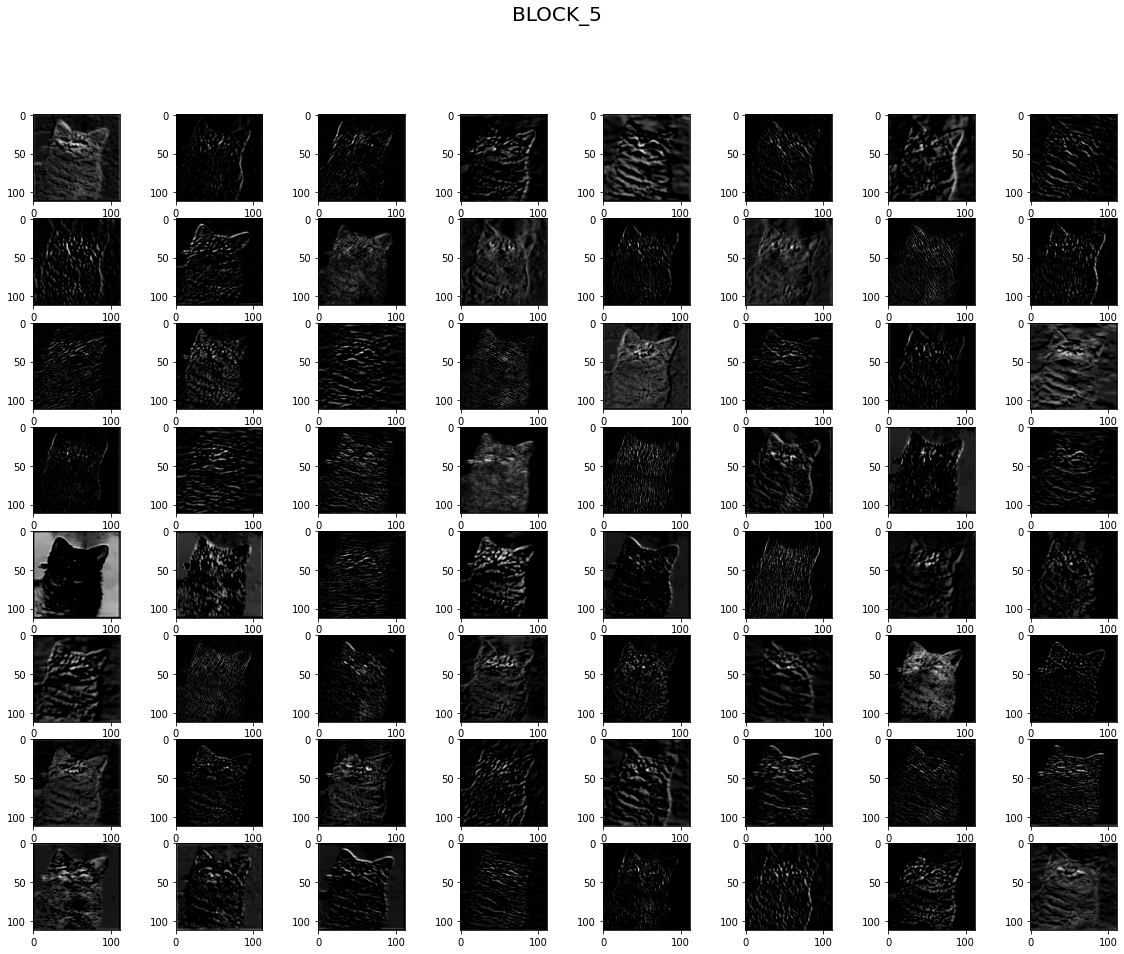

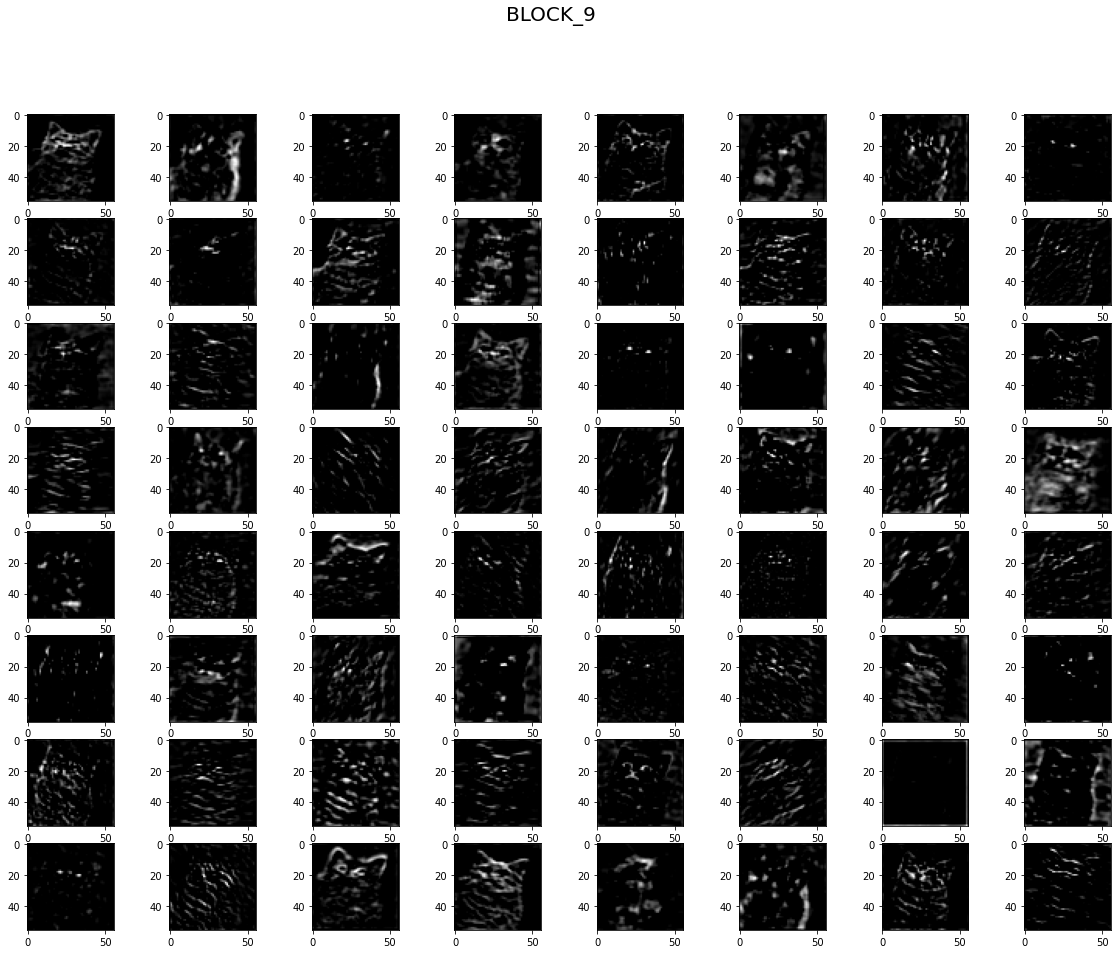

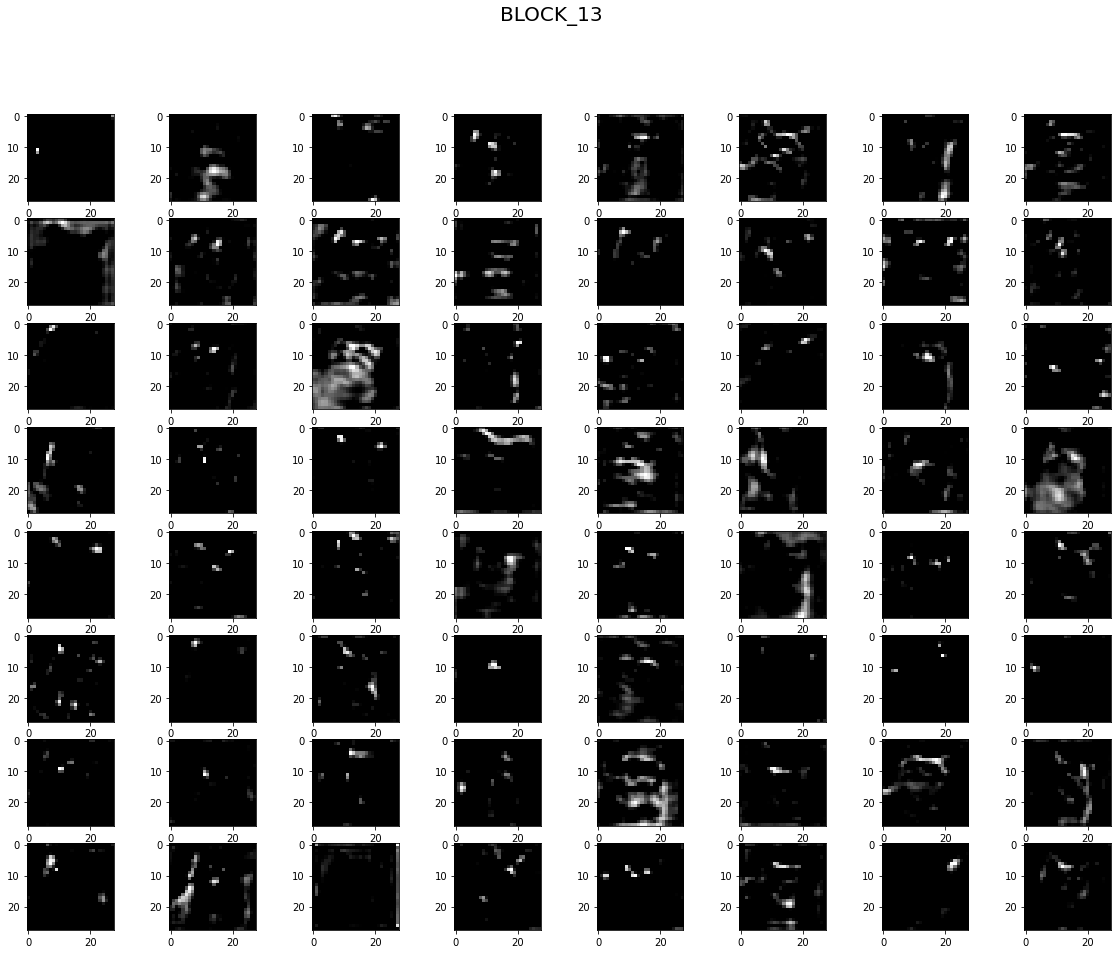

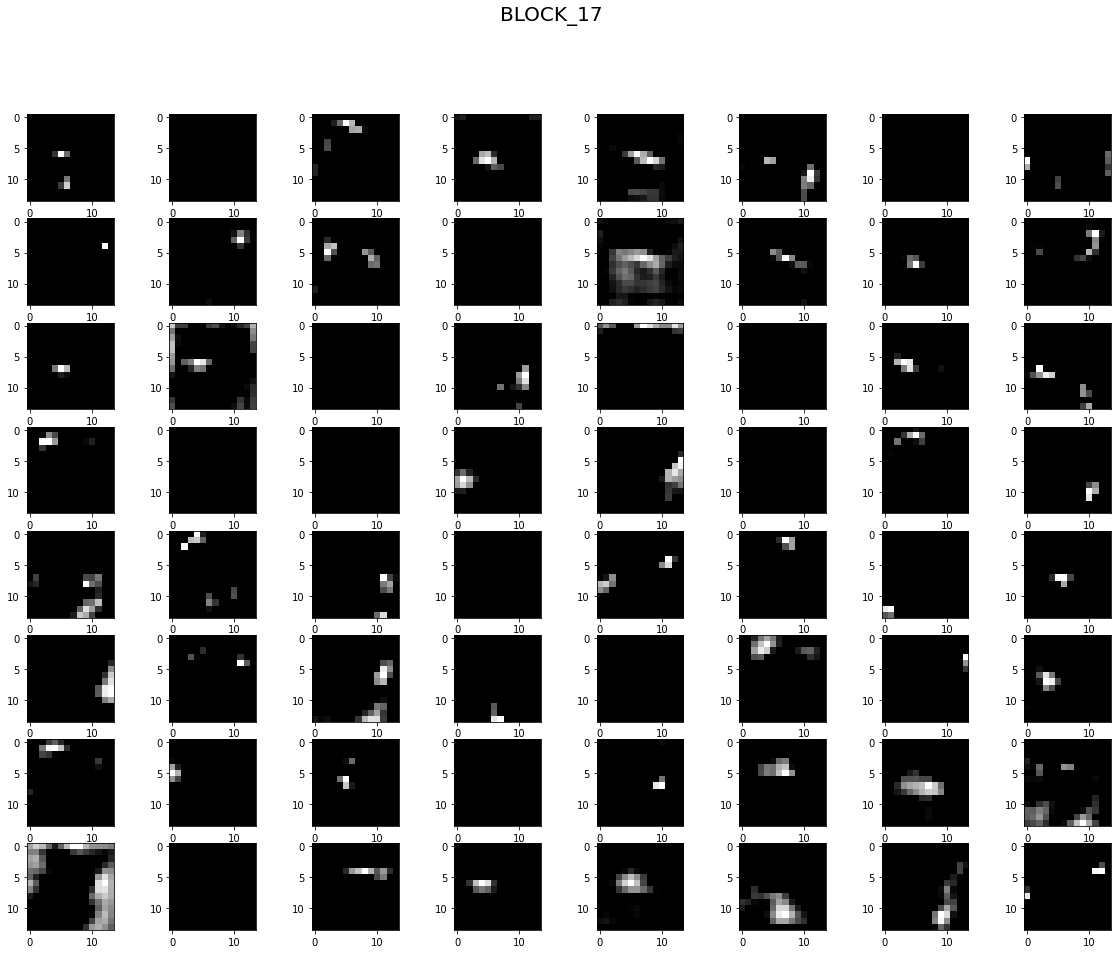

In [37]:
feature_map = model2.predict(image)

for i,fmap in zip(blocks,feature_map):
    fig = pyplot.figure(figsize=(20,15))
    #https://stackoverflow.com/a/12444777
    fig.suptitle("BLOCK_{}".format(i) , fontsize=20)
    for i in range(1,features.shape[3]+1):

        pyplot.subplot(8,8,i)
        pyplot.imshow(fmap[0,:,:,i-1] , cmap='gray')
    
pyplot.show()